Part 1: Encoding the Treatment Factors (The Bilinear Map)
First, we must mathematically define how the factors "ICB" ($u_{icb}$) and "Mutagen" ($u_{mut}$) alter your parameters. Because combination therapy is highly synergistic (the combination effect does not just equal the sum of the individual effects),

# T11 cells

In [10]:
import numpy as np

# ==========================================
# 1. Base & Treatment Parameters (From Table)
# ==========================================
# Fixed parameters for T11
fixed_p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "K_C": 0.4, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, "K_D": 4e-4,
    "d_T8": 0.001, "d_D": 0.3, "K_Treg": 0.0001, "d_N": 0.13 # From table bottom rows
}

# The four treatment states mapping the 4 changing parameters
# Format: [lambda_T8_comb, lambda_DC_comb, lambda_Tr_comb, sigma_N]
P_untreated = np.array([3e-06, 0.0095, 0.00025, 0.0005])
P_ici       = np.array([3.5e-05, 0.00225, 0.0003, 0.00045])
P_mutagen   = np.array([0.0002, 0.002, 0.0003, 0.0004])
P_comb      = np.array([0.0005, 0.003, 0.0003, 0.0005])

# ==========================================
# 2. Treatment Encoder
# ==========================================
def get_encoded_params(u_icb, u_mut):
    """
    Bilinear interpolation to encode treatment dosages into biological parameters.
    u_icb, u_mut are floats between 0.0 (off) and 1.0 (max dose).
    """
    # Bilinear formula: P(x,y) = P00(1-x)(1-y) + P10(x)(1-y) + P01(1-x)(y) + P11(x)(y)
    P_current = (P_untreated * (1 - u_icb) * (1 - u_mut) + 
                 P_ici       * u_icb       * (1 - u_mut) + 
                 P_mutagen   * (1 - u_icb) * u_mut       + 
                 P_comb      * u_icb       * u_mut)
                 
    # Combine with fixed parameters
    p = fixed_p.copy()
    p["lambda_T8_comb"] = P_current[0]
    p["lambda_DC_comb"] = P_current[1]
    p["lambda_Tr_comb"] = P_current[2]
    p["sigma_N"]        = P_current[3]
    return p

ODE & Gillespie Back-to-Back Simulations
Here we run the 30-day time course. To compare the treatments "back-to-back", this code generates a 5x3 grid of subplots (5 cell types $\times$ 3 treatment groups), plotting the smooth ODE trajectory and the stochastic Gillespie trajectory on top of each other, matching the style you provided.

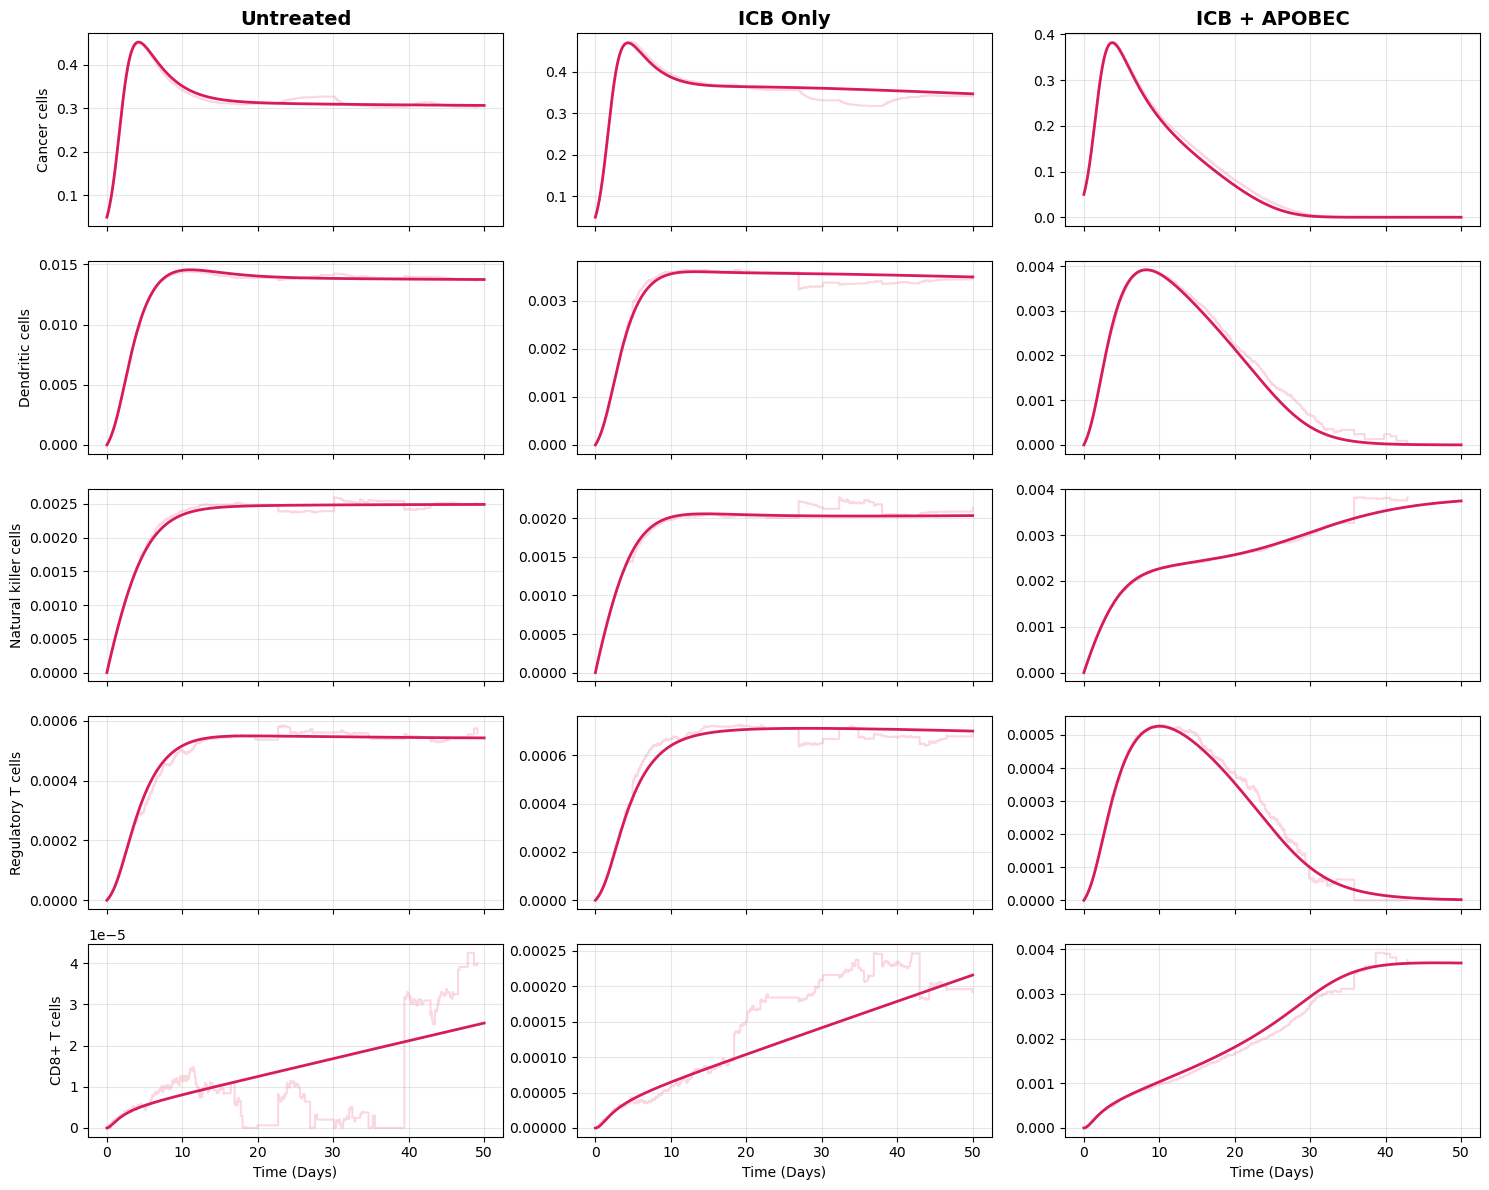

In [11]:
import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.05, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 50.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Start with no immune cells and 0.4 level of tumor cells. 

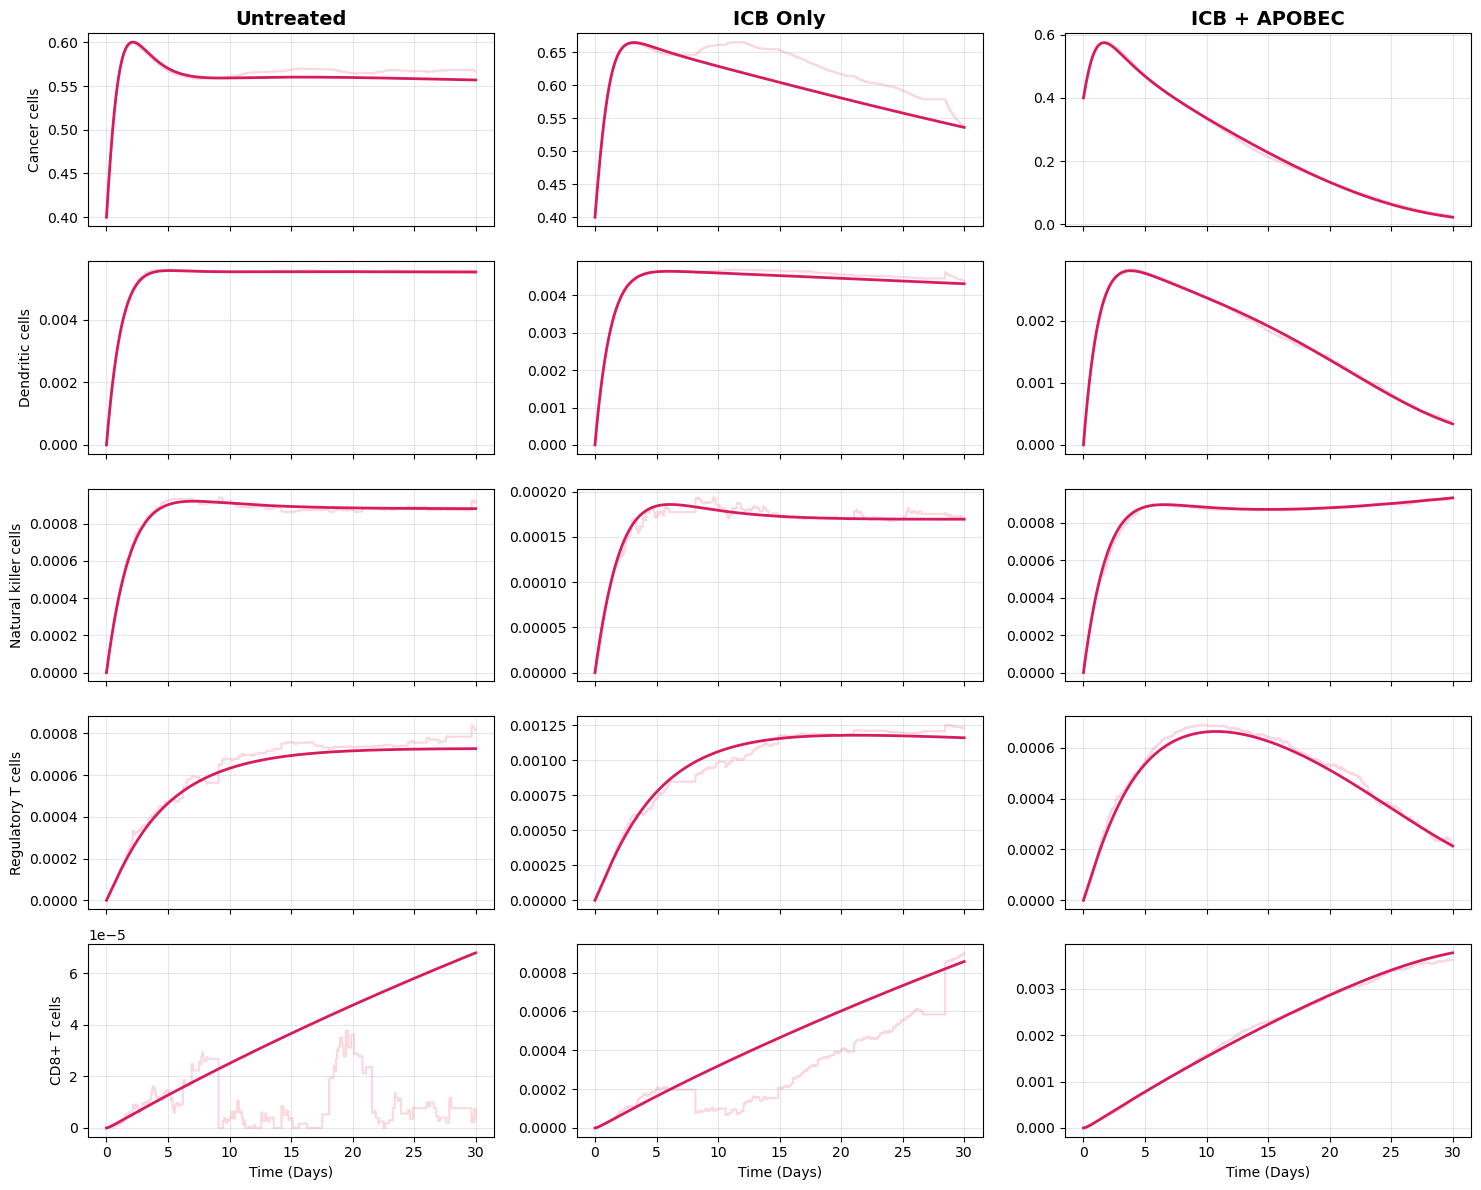

In [8]:
import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.4, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 30.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Starting Synergistic Optimal Control...


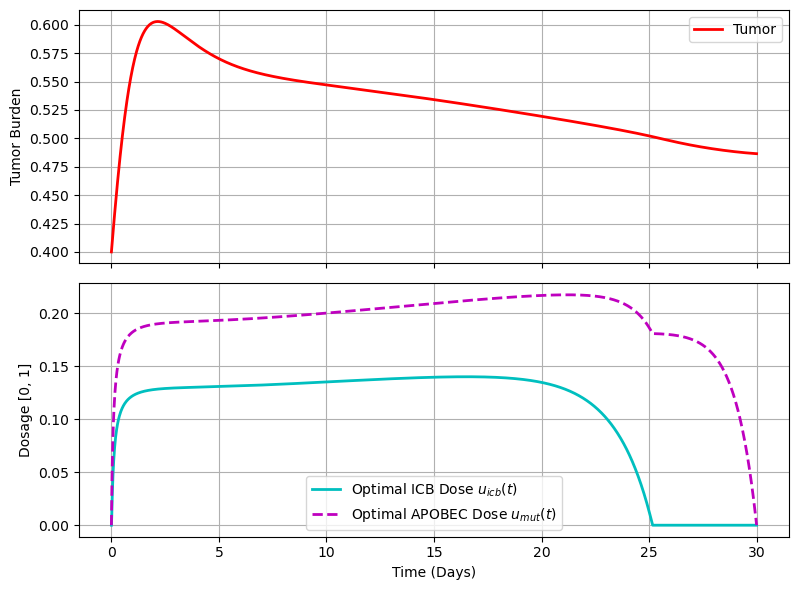

In [9]:
# ==========================================
# 1. FBSM Setup & Adjoint Partial Derivatives
# ==========================================
N_steps = 2000
dt = T_days / N_steps
t_opt = np.linspace(0, T_days, N_steps)

# Cost Weights
w_icb = 0.05
w_mut = 0.05
b_val = 1.0 # High penalty on final tumor size

def get_param_gradients(u_icb, u_mut):
    """Calculates partial derivatives of the parameters with respect to controls"""
    # dP/du_icb = -P_un(1-u_mut) + P_ici(1-u_mut) - P_mut*u_mut + P_comb*u_mut
    dp_dicb = -P_untreated*(1 - u_mut) + P_ici*(1 - u_mut) - P_mutagen*u_mut + P_comb*u_mut
    
    # dP/du_mut = -P_un(1-u_icb) - P_ici*u_icb + P_mutagen*(1-u_icb) + P_comb*u_icb
    dp_dmut = -P_untreated*(1 - u_icb) - P_ici*u_icb + P_mutagen*(1 - u_icb) + P_comb*u_icb
    return dp_dicb, dp_dmut

def adjoint_derivatives(x, lam, u_icb, u_mut):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    p = get_encoded_params(u_icb, u_mut)
    d_Treg = p.get("d_Treg", 0.2)
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["lambda_DC_comb"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["lambda_Tr_comb"] * p["K_C"] / den_KC**2) )
    dl2 = -( -l2*p["d_D"] + l5*(p["lambda_T8_comb"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*d_Treg + l5*(p["lambda_T8_comb"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 2. FBSM Loop
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0

u_icb = np.zeros(N_steps)
u_mut = np.zeros(N_steps)

tolerance = 1e-3
max_iter = 100
iteration = 0
test = 1.0

print("Starting Synergistic Optimal Control...")

while test > tolerance and iteration < max_iter:
    old_icb, old_mut, old_x = u_icb.copy(), u_mut.copy(), x_opt.copy()
    
    # Forward Sweep
    for i in range(N_steps - 1):
        x_opt[:, i+1] = x_opt[:, i] + dt * ode_derivatives(x_opt[:, i], get_encoded_params(u_icb[i], u_mut[i]))
        x_opt[:, i+1] = np.maximum(x_opt[:, i+1], 0)
        
    # Backward Sweep
    lam[0, -1] = b_val 
    lam[1:, -1] = 0.0
    for i in range(N_steps - 1, 0, -1):
        lam[:, i-1] = lam[:, i] - dt * adjoint_derivatives(x_opt[:, i], lam[:, i], u_icb[i], u_mut[i])
        
    # Control Update using Gradients
    new_icb = np.zeros(N_steps)
    new_mut = np.zeros(N_steps)
    
    for i in range(N_steps):
        dp_dicb, dp_dmut = get_param_gradients(u_icb[i], u_mut[i])
        
        # dH/du_icb calculation based on how params affect ODEs
        # (Simplified to primary pathways based on table parameters)
        grad_icb = ( lam[4,i]*(dp_dicb[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dicb[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dicb[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dicb[3] )
                     
        grad_mut = ( lam[4,i]*(dp_dmut[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dmut[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dmut[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dmut[3] )

        new_icb[i] = np.clip(-grad_icb / w_icb, 0.0, 1.0)
        new_mut[i] = np.clip(-grad_mut / w_mut, 0.0, 1.0)
        
    u_icb = 0.5 * new_icb + 0.5 * old_icb
    u_mut = 0.5 * new_mut + 0.5 * old_mut
    
    test = np.sum(np.abs(u_icb - old_icb)) + np.sum(np.abs(u_mut - old_mut))
    iteration += 1

# Plot Optimal Control
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(t_opt, x_opt[0, :], 'r-', linewidth=2, label='Tumor')
ax1.set_ylabel("Tumor Burden")
ax1.legend()
ax1.grid()

ax2.plot(t_opt, u_icb, 'c-', linewidth=2, label='Optimal ICB Dose $u_{icb}(t)$')
ax2.plot(t_opt, u_mut, 'm--', linewidth=2, label='Optimal APOBEC Dose $u_{mut}(t)$')
ax2.set_ylabel("Dosage [0, 1]")
ax2.set_xlabel("Time (Days)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

# KPB25L Cell Line

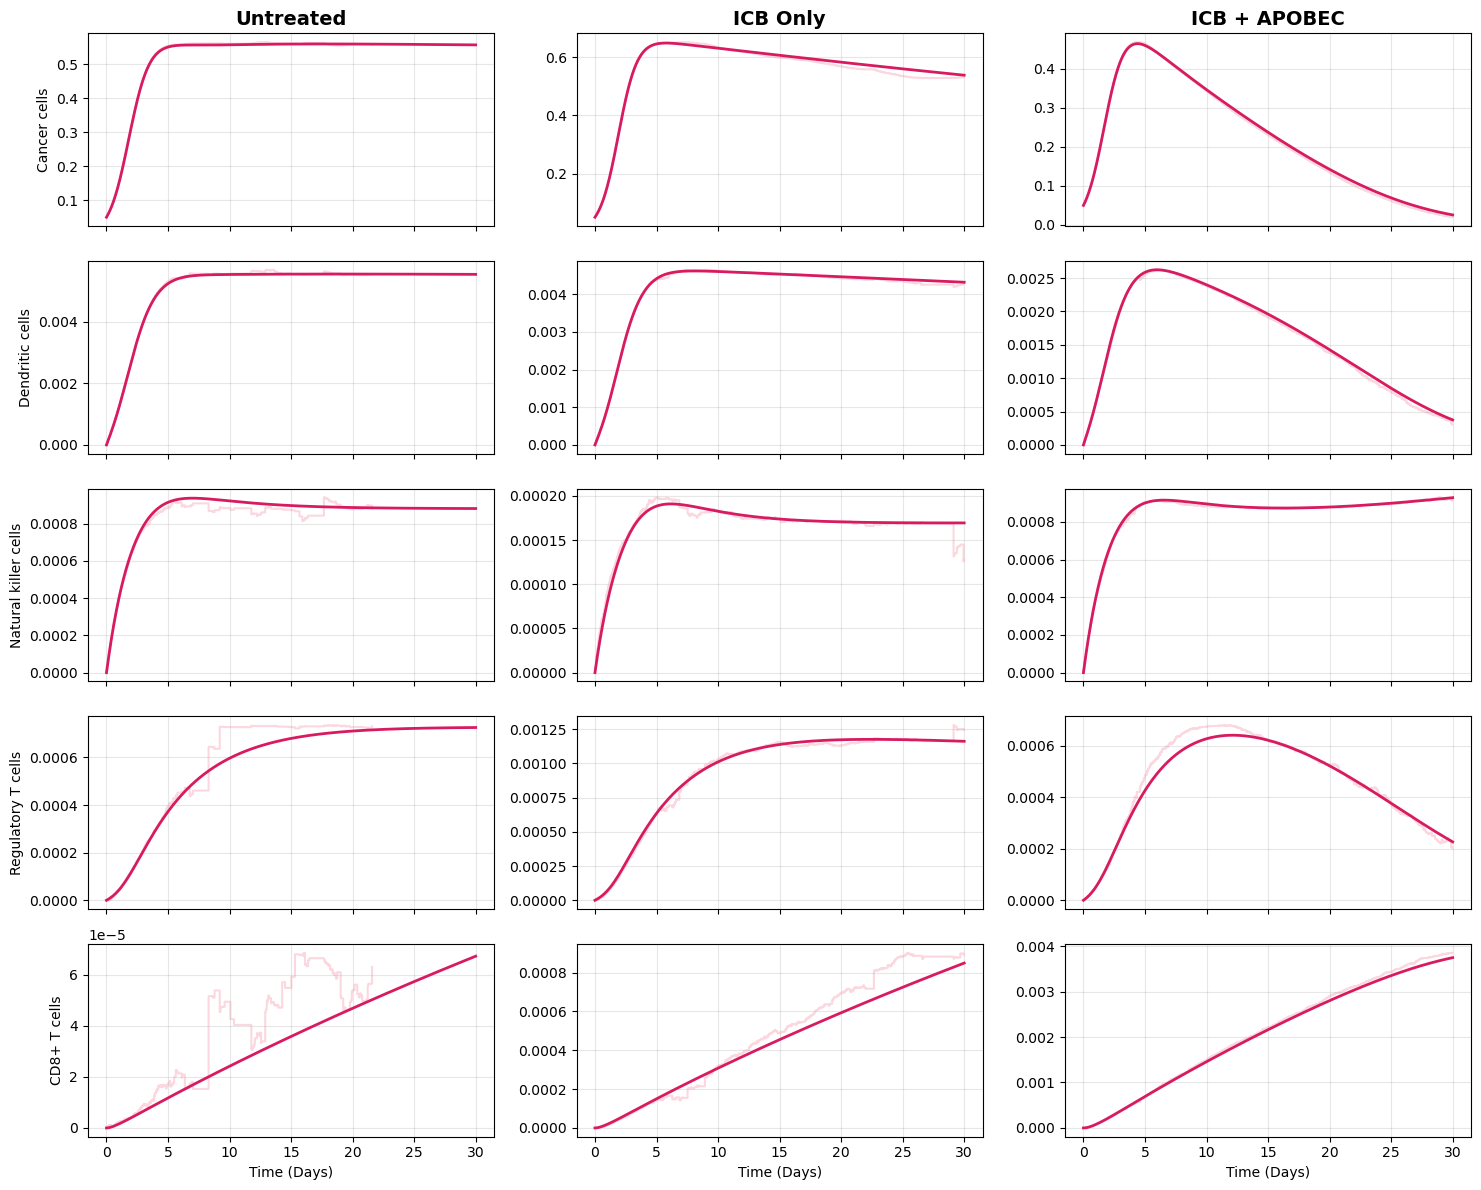

In [5]:
import numpy as np

# ==========================================
# 1. Base & Treatment Parameters (From Table)
# ==========================================
# Fixed parameters for T11
fixed_p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "K_C": 0.4, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4, "K_D": 4e-4,
    "d_T8": 0.01, "d_D": 1.0, "K_Treg": 0.01, "d_N": 0.5 # From table bottom rows
}

# The four treatment states mapping the 4 changing parameters
# Format: [lambda_T8_comb, lambda_DC_comb, lambda_Tr_comb, sigma_N]
P_untreated = np.array([3e-06, 0.0095, 0.00025, 0.0005])
P_ici       = np.array([4e-05, 0.0075, 0.0004, 0.0001])
P_mutagen   = np.array([7e-05, 0.0095, 0.0003, 0.0005])
P_comb      = np.array([0.0002, 0.005, 0.0003, 0.0005])

def get_encoded_params(u_icb, u_mut):
    P_current = (P_untreated * (1 - u_icb) * (1 - u_mut) + 
                 P_ici       * u_icb       * (1 - u_mut) + 
                 P_mutagen   * (1 - u_icb) * u_mut       + 
                 P_comb      * u_icb       * u_mut)
                 
    p = fixed_p.copy()
    p["lambda_T8_comb"] = P_current[0]
    p["lambda_DC_comb"] = P_current[1]
    p["lambda_Tr_comb"] = P_current[2]
    p["sigma_N"]        = P_current[3]
    return p


import matplotlib.pyplot as plt

# ==========================================
# 1. ODE and Gillespie Core Functions
# ==========================================
def ode_derivatives(x, p):
    C, D, N, Tr, T8 = np.maximum(x, 0)
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["lambda_DC_comb"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C) if "d_Treg" in p else -0.2*Tr + p["lambda_Tr_comb"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"]))
    
    return np.array([dC, dD, dN, dTr, dT8])

def run_ode(p, x0, T, dt=0.01):
    steps = int(T / dt)
    x = np.zeros((5, steps))
    t = np.linspace(0, T, steps)
    x[:, 0] = x0
    for i in range(steps - 1):
        k1 = dt * ode_derivatives(x[:, i], p)
        k2 = dt * ode_derivatives(x[:, i] + 0.5*k1, p)
        k3 = dt * ode_derivatives(x[:, i] + 0.5*k2, p)
        k4 = dt * ode_derivatives(x[:, i] + k3, p)
        x[:, i+1] = np.maximum(x[:, i] + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0)
    return t, x

def gillespie_scaled(p, x0, T, scale=2000):
    # Simplified Tau-Leaping/Scaled Gillespie for performance over 30 days
    t = [0]
    x = [np.array(x0)]
    curr_t = 0
    curr_x = np.array(x0)
    
    while curr_t < T:
        rates = ode_derivatives(curr_x, p) * scale
        total_rate = np.sum(np.abs(rates)) + 1e-10
        
        # Time step
        dt = np.random.exponential(1.0 / total_rate)
        curr_t += dt
        if curr_t > T: break
            
        # Add deterministic drift with noise scaled by sqrt(rate)
        noise = np.random.normal(0, 1, 5) * np.sqrt(np.abs(rates)) / scale
        curr_x = np.maximum(curr_x + ode_derivatives(curr_x, p)*dt + noise*dt, 0)
        
        t.append(curr_t)
        x.append(curr_x.copy())
    return np.array(t), np.array(x).T

# ==========================================
# 2. Run and Plot Setup
# ==========================================
# x0 = [0.8, 0.0, 0.0, 0.0, 0.0] # Initial conditions
x0 = [0.05, 0.0, 0.0, 0.0,0.0] # give tumor time to grow
T_days = 30.0

groups = [
    ("Untreated", get_encoded_params(0.0, 0.0)),
    ("ICB Only", get_encoded_params(1.0, 0.0)),
    ("ICB + APOBEC", get_encoded_params(1.0, 1.0))
]

fig, ax = plt.subplots(5, 3, figsize=(15, 12), sharex=True)
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
c_ode = (216/255, 27/255, 96/255) # Deep pink
c_stoch = (250/255, 200/255, 210/255) # Light pink

for col, (g_name, p_group) in enumerate(groups):
    ax[0, col].set_title(g_name, fontsize=14, fontweight='bold')
    
    t_ode, x_ode = run_ode(p_group, x0, T_days)
    t_g, x_g = gillespie_scaled(p_group, x0, T_days, scale=5000)
    
    for row in range(5):
        ax[row, col].plot(t_ode, x_ode[row, :], color=c_ode, linewidth=2, zorder=5)
        ax[row, col].step(t_g, x_g[row, :], color=c_stoch, where='post', alpha=0.7, zorder=1)
        if col == 0: ax[row, col].set_ylabel(titles[row], fontsize=10)
        if row == 4: ax[row, col].set_xlabel("Time (Days)")
        ax[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Starting Synergistic Optimal Control...


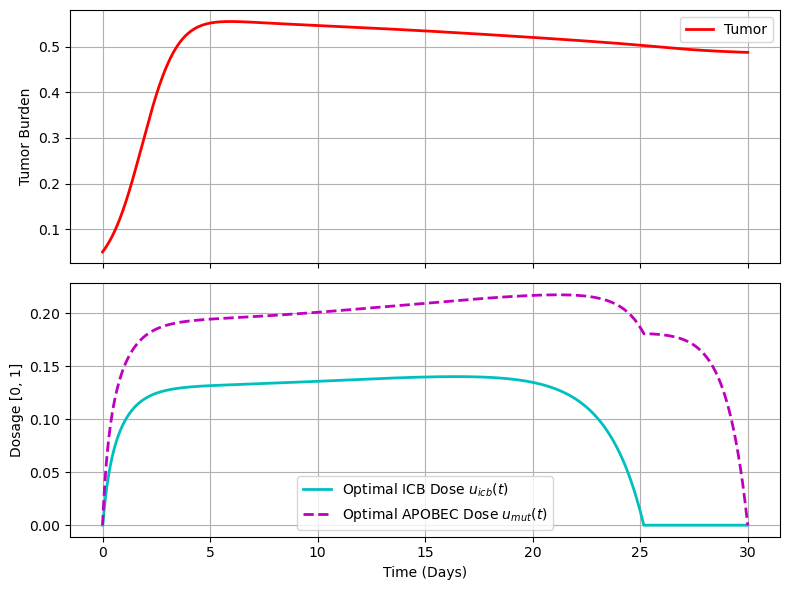

In [6]:
# ==========================================
# 1. FBSM Setup & Adjoint Partial Derivatives
# ==========================================
N_steps = 2000
dt = T_days / N_steps
t_opt = np.linspace(0, T_days, N_steps)

# Cost Weights
w_icb = 0.05
w_mut = 0.05
b_val = 1.0 # High penalty on final tumor size

def get_param_gradients(u_icb, u_mut):
    """Calculates partial derivatives of the parameters with respect to controls"""
    # dP/du_icb = -P_un(1-u_mut) + P_ici(1-u_mut) - P_mut*u_mut + P_comb*u_mut
    dp_dicb = -P_untreated*(1 - u_mut) + P_ici*(1 - u_mut) - P_mutagen*u_mut + P_comb*u_mut
    
    # dP/du_mut = -P_un(1-u_icb) - P_ici*u_icb + P_mutagen*(1-u_icb) + P_comb*u_icb
    dp_dmut = -P_untreated*(1 - u_icb) - P_ici*u_icb + P_mutagen*(1 - u_icb) + P_comb*u_icb
    return dp_dicb, dp_dmut

def adjoint_derivatives(x, lam, u_icb, u_mut):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    p = get_encoded_params(u_icb, u_mut)
    d_Treg = p.get("d_Treg", 0.2)
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["lambda_DC_comb"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["lambda_Tr_comb"] * p["K_C"] / den_KC**2) )
    dl2 = -( -l2*p["d_D"] + l5*(p["lambda_T8_comb"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*d_Treg + l5*(p["lambda_T8_comb"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 2. FBSM Loop
# ==========================================
x_opt = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x_opt[:, 0] = x0

u_icb = np.zeros(N_steps)
u_mut = np.zeros(N_steps)

tolerance = 1e-3
max_iter = 100
iteration = 0
test = 1.0

print("Starting Synergistic Optimal Control...")

while test > tolerance and iteration < max_iter:
    old_icb, old_mut, old_x = u_icb.copy(), u_mut.copy(), x_opt.copy()
    
    # Forward Sweep
    for i in range(N_steps - 1):
        x_opt[:, i+1] = x_opt[:, i] + dt * ode_derivatives(x_opt[:, i], get_encoded_params(u_icb[i], u_mut[i]))
        x_opt[:, i+1] = np.maximum(x_opt[:, i+1], 0)
        
    # Backward Sweep
    lam[0, -1] = b_val 
    lam[1:, -1] = 0.0
    for i in range(N_steps - 1, 0, -1):
        lam[:, i-1] = lam[:, i] - dt * adjoint_derivatives(x_opt[:, i], lam[:, i], u_icb[i], u_mut[i])
        
    # Control Update using Gradients
    new_icb = np.zeros(N_steps)
    new_mut = np.zeros(N_steps)
    
    for i in range(N_steps):
        dp_dicb, dp_dmut = get_param_gradients(u_icb[i], u_mut[i])
        
        # dH/du_icb calculation based on how params affect ODEs
        # (Simplified to primary pathways based on table parameters)
        grad_icb = ( lam[4,i]*(dp_dicb[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dicb[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dicb[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dicb[3] )
                     
        grad_mut = ( lam[4,i]*(dp_dmut[0] * x_opt[1,i]/(fixed_p["K_D"]+x_opt[1,i]) * (1/(1+x_opt[3,i]/fixed_p["K_Treg"]))) +
                     lam[1,i]*(dp_dmut[1] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[3,i]*(dp_dmut[2] * x_opt[0,i]/(fixed_p["K_C"]+x_opt[0,i])) +
                     lam[2,i]*dp_dmut[3] )

        new_icb[i] = np.clip(-grad_icb / w_icb, 0.0, 1.0)
        new_mut[i] = np.clip(-grad_mut / w_mut, 0.0, 1.0)
        
    u_icb = 0.5 * new_icb + 0.5 * old_icb
    u_mut = 0.5 * new_mut + 0.5 * old_mut
    
    test = np.sum(np.abs(u_icb - old_icb)) + np.sum(np.abs(u_mut - old_mut))
    iteration += 1

# Plot Optimal Control
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(t_opt, x_opt[0, :], 'r-', linewidth=2, label='Tumor')
ax1.set_ylabel("Tumor Burden")
ax1.legend()
ax1.grid()

ax2.plot(t_opt, u_icb, 'c-', linewidth=2, label='Optimal ICB Dose $u_{icb}(t)$')
ax2.plot(t_opt, u_mut, 'm--', linewidth=2, label='Optimal APOBEC Dose $u_{mut}(t)$')
ax2.set_ylabel("Dosage [0, 1]")
ax2.set_xlabel("Time (Days)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()